<a href="https://colab.research.google.com/github/lakithav/ml-internship-journey/blob/main/Principal_Component_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.array([[40, 20],
                [55, 30],
                [70, 60],
                [50, 35],
                [45, 40],
                [62, 75],
                [45, 30],
                [68, 80],
                [80, 70],
                [75, 90]])

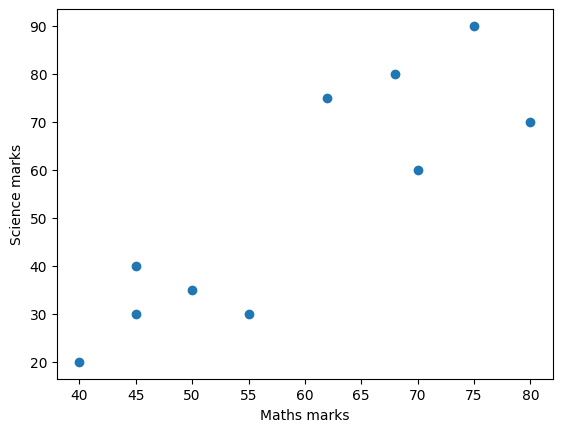

In [3]:
plt.scatter(data[:,0],data[:,1])
plt.xlabel("Maths marks")
plt.ylabel("Science marks")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)

[[-1.43299332 -1.39951173]
 [-0.3016828  -0.97541727]
 [ 0.82962771  0.29686613]
 [-0.67878631 -0.76337004]
 [-1.05588981 -0.5513228 ]
 [ 0.2262621   0.93300782]
 [-1.05588981 -0.97541727]
 [ 0.67878631  1.14505506]
 [ 1.58383472  0.72096059]
 [ 1.20673122  1.56914952]]


In [8]:
from sklearn.decomposition import PCA

pca=PCA(n_components=1)
pca.fit(scaled_data)

PCA(n_components=1)

In [9]:
pca.explained_variance_

array([2.07778406])

In [10]:
pca.explained_variance_ratio_

array([0.93500282])

In [11]:
pca_scaled_data = pca.transform(scaled_data)

In [14]:
scaled_data.shape

(10, 2)

In [15]:
pca_scaled_data.shape

(10, 1)

In [16]:
pca_scaled_data = pca.inverse_transform(pca_scaled_data)


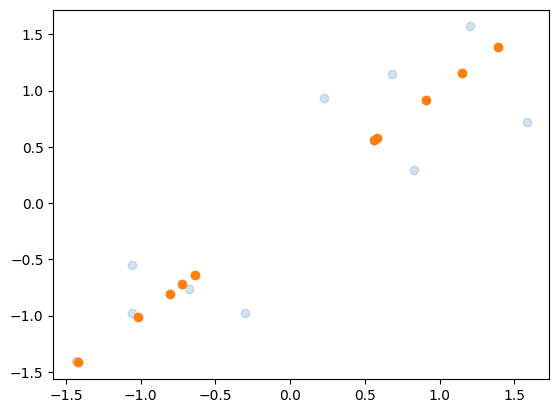

In [20]:
plt.scatter(scaled_data[:,0],scaled_data[:,1],alpha = 0.2)
plt.scatter(pca_scaled_data[:,0],pca_scaled_data[:,1])

PCA for visualization

In [1]:
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()
digits.data.shape

(1797, 64)

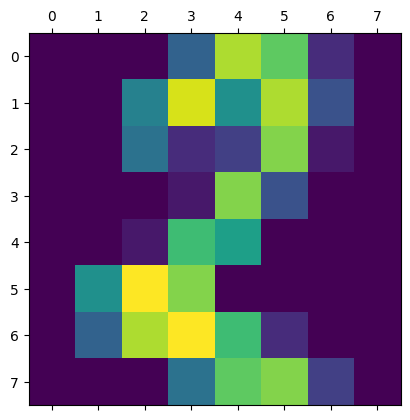

In [6]:
import matplotlib.pyplot as plt
plt.matshow(digits.images[50])
plt.show()

In [7]:
digits.target[50]

np.int64(2)

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
new_digits = pca.fit_transform(digits.data)

In [11]:
new_digits.data.shape

(1797, 2)

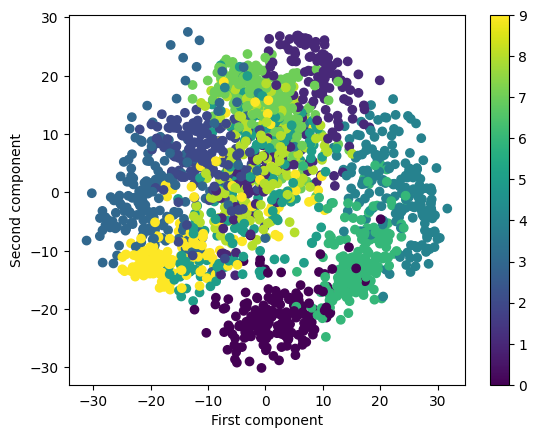

In [13]:
plt.scatter(new_digits[:,0],new_digits[:,1],c=digits.target)
plt.colorbar()
plt.xlabel("First component")
plt.ylabel("Second component")
plt.show()

PCA for speedup models

In [14]:
digits.data.shape

(1797, 64)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
new_data = scaler.fit_transform(digits.data)

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
new_data_pca = pca.fit_transform(new_data)

In [31]:
new_data_pca.shape

(1797, 10)

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(new_data_pca,digits.target,test_size=0.2,random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='lbfgs')

import time
start =time.time()
model.fit(X_train,y_train)
end=time.time()
print((end-start)*1000)

64.8345947265625


In [34]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

0.8972222222222223